# CNN-Based Road Accident Severity Classification Using Transfer Learning

This Kaggle notebook implements Phase 2 technical implementation for the Machine Learning & Smart Systems CNN image classification project.

**Dataset:** Road Accidents from CCTV Footages Dataset  
**Task:** Classify accident severity into Minor Impact, Substantial Impact, and Critical Impact.

Models included:
1. Custom CNN baseline
2. MobileNetV2 transfer learning
3. EfficientNetB0 transfer learning

Outputs saved to `/kaggle/working/results/`.

In [1]:
# ============================================================
# 1. Install / Import Libraries
# ============================================================
import os
import json
import time
import shutil
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

RESULTS_DIR = Path('/kaggle/working/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print('Results folder:', RESULTS_DIR)

2026-06-27 18:43:19.478365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782585799.682000      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782585799.740895      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782585800.165693      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782585800.165731      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782585800.165734      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Results folder: /kaggle/working/results


In [2]:
# ============================================================
# 2. Locate Dataset Automatically in Kaggle Input
# ============================================================
INPUT_ROOT = Path('/kaggle/input')

def find_severity_dataset(root: Path):
    candidate_names = ['Severity Score Dataset', 'SeverityScore', 'severity score dataset', 'severityscore']
    for path in root.rglob('*'):
        if path.is_dir():
            subdirs = sorted([p.name for p in path.iterdir() if p.is_dir()])
            if set(['1', '2', '3']).issubset(set(subdirs)):
                return path
    return None

DATASET_DIR = find_severity_dataset(INPUT_ROOT)

if DATASET_DIR is None:
    print('Could not automatically find folders 1, 2, 3.')
    print('Available folders under /kaggle/input:')
    for p in INPUT_ROOT.rglob('*'):
        if p.is_dir():
            print(p)
    raise FileNotFoundError('Dataset folder with class folders 1, 2, 3 was not found. Please check Kaggle dataset input path.')

print('Dataset directory found:', DATASET_DIR)
print('Class folders:', [p.name for p in DATASET_DIR.iterdir() if p.is_dir()])

Dataset directory found: /kaggle/input/datasets/suryaprabhakaran2005/road-accidents-from-cctv-footages-dataset/SeverityScore/Severity Score Dataset with Labels
Class folders: ['2', '3', '1']


In [3]:
# ============================================================
# 3. Build File List and Labels
# ============================================================
class_map = {
    '1': 'Minor Impact',
    '2': 'Substantial Impact',
    '3': 'Critical Impact'
}

image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
file_paths = []
labels = []

for folder_name, class_name in class_map.items():
    folder = DATASET_DIR / folder_name
    if not folder.exists():
        raise FileNotFoundError(f'Missing class folder: {folder}')
    for img_path in folder.rglob('*'):
        if img_path.suffix.lower() in image_extensions:
            file_paths.append(str(img_path))
            labels.append(folder_name)

df = pd.DataFrame({'filepath': file_paths, 'label_code': labels})
df['label_name'] = df['label_code'].map(class_map)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Total images:', len(df))
print(df['label_name'].value_counts())
df.head()

Total images: 6191
label_name
Critical Impact       2217
Substantial Impact    2100
Minor Impact          1874
Name: count, dtype: int64


,filepath,label_code,label_name
0,/kaggle/input/datasets/suryaprabhakaran2005/ro...,1,Minor Impact
1,/kaggle/input/datasets/suryaprabhakaran2005/ro...,1,Minor Impact
2,/kaggle/input/datasets/suryaprabhakaran2005/ro...,3,Critical Impact
3,/kaggle/input/datasets/suryaprabhakaran2005/ro...,2,Substantial Impact
4,/kaggle/input/datasets/suryaprabhakaran2005/ro...,2,Substantial Impact


In [4]:
# ============================================================
# 4. Save Dataset Description Table and Class Distribution
# ============================================================
dataset_summary = df['label_name'].value_counts().reset_index()
dataset_summary.columns = ['Class', 'Number of Images']
dataset_summary['Percentage'] = (dataset_summary['Number of Images'] / len(df) * 100).round(2)
dataset_summary.to_csv(RESULTS_DIR / 'dataset_description_table.csv', index=False)
dataset_summary

,Class,Number of Images,Percentage
0,Critical Impact,2217,35.81
1,Substantial Impact,2100,33.92
2,Minor Impact,1874,30.27


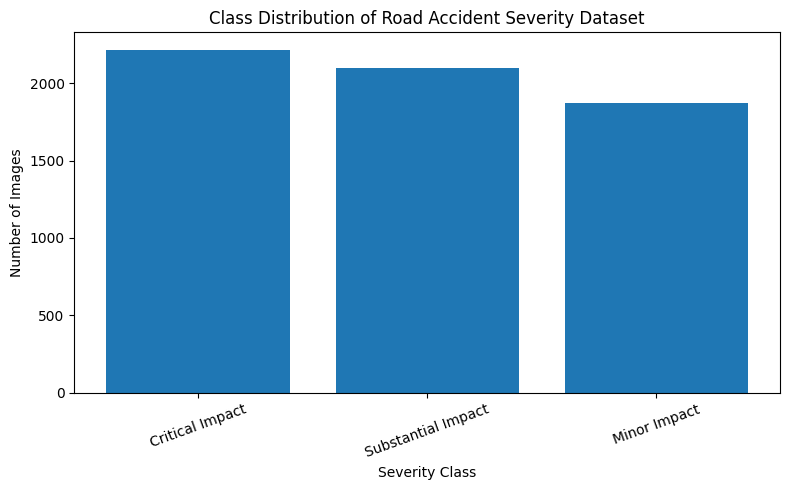

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(dataset_summary['Class'], dataset_summary['Number of Images'])
plt.title('Class Distribution of Road Accident Severity Dataset')
plt.xlabel('Severity Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=300)
plt.show()

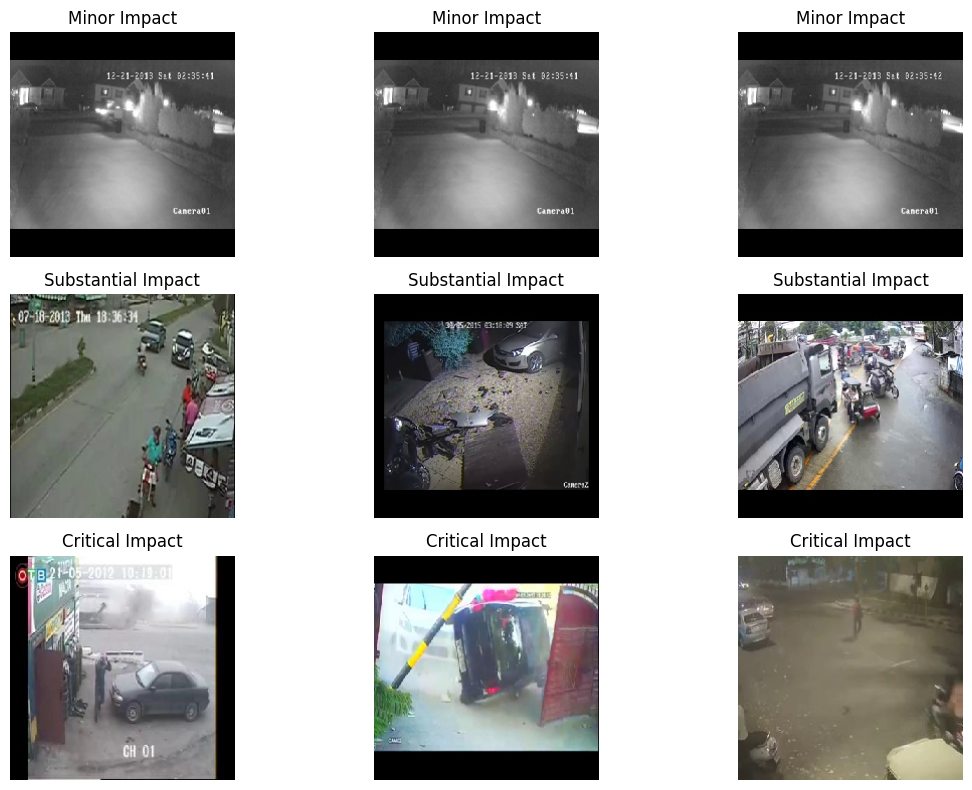

In [6]:
# ============================================================
# 5. Show Sample Images from Each Class
# ============================================================
plt.figure(figsize=(12, 8))
plot_idx = 1
for label_name in class_map.values():
    sample_files = df[df['label_name'] == label_name]['filepath'].sample(min(3, len(df[df['label_name'] == label_name])), random_state=SEED).tolist()
    for fp in sample_files:
        img = keras.utils.load_img(fp, target_size=(224, 224))
        plt.subplot(3, 3, plot_idx)
        plt.imshow(img)
        plt.title(label_name)
        plt.axis('off')
        plot_idx += 1
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=300)
plt.show()

In [7]:
# ============================================================
# 6. Train / Validation / Test Split
# ============================================================
label_to_index = {'1': 0, '2': 1, '3': 2}
df['label_index'] = df['label_code'].map(label_to_index)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label_index'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label_index'], random_state=SEED
)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

split_summary = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Images': [len(train_df), len(val_df), len(test_df)]
})
split_summary.to_csv(RESULTS_DIR / 'data_split_table.csv', index=False)
split_summary

Train: 4333
Validation: 929
Test: 929


,Split,Images
0,Train,4333
1,Validation,929
2,Test,929


In [8]:
# ============================================================
# 7. Create TensorFlow Data Pipelines
# ============================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def make_dataset(dataframe, shuffle=False):
    paths = dataframe['filepath'].values
    labels = dataframe['label_index'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

class_names = ['Minor Impact', 'Substantial Impact', 'Critical Impact']
print(class_names)

I0000 00:00:1782585829.583834      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782585829.589897      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


['Minor Impact', 'Substantial Impact', 'Critical Impact']


In [9]:
# ============================================================
# 8. Data Augmentation Layer
# ============================================================
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='data_augmentation')

In [10]:
# ============================================================
# 9. Helper Functions for Training, Evaluation, and Plotting
# ============================================================
def plot_training_curves(history, model_name):
    hist = pd.DataFrame(history.history)
    hist.to_csv(RESULTS_DIR / f'{model_name}_training_history.csv', index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(hist['accuracy'], label='Training Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_accuracy_curve.png', dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_loss_curve.png', dpi=300)
    plt.show()

def evaluate_model(model, dataset, model_name):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_prob.extend(probs)
        y_pred.extend(np.argmax(probs, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(RESULTS_DIR / f'{model_name}_classification_report.csv')

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.to_csv(RESULTS_DIR / f'{model_name}_confusion_matrix.csv')

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{model_name} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], horizontalalignment='center')
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{model_name}_confusion_matrix.png', dpi=300)
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Macro Precision': round(prec, 4),
        'Macro Recall': round(rec, 4),
        'Macro F1-Score': round(f1, 4),
        'Weighted F1-Score': round(weighted_f1, 4),
        'Parameters': int(model.count_params())
    }

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3, min_lr=1e-6)

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,699 (1.61 MB)

 Trainable params: 421,699 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8


I0000 00:00:1782585836.839487     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


136/136 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.3840 - loss: 1.0849 - val_accuracy: 0.4736 - val_loss: 1.0471 - learning_rate: 1.0000e-04
Epoch 2/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - accuracy: 0.4957 - loss: 0.9896 - val_accuracy: 0.5468 - val_loss: 0.9410 - learning_rate: 1.0000e-04
Epoch 3/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5317 - loss: 0.9265 - val_accuracy: 0.4930 - val_loss: 0.9556 - learning_rate: 1.0000e-04
Epoch 4/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5532 - loss: 0.8955 - val_accuracy: 0.5264 - val_loss: 0.8985 - learning_rate: 1.0000e-04
Epoch 5/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.5830 - loss: 0.8597 - val_accuracy: 0.5328 - val_loss: 0.8929 - learning_rate: 1.0000e-04
Epoch 6/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5878 - loss: 0.8347 - val_accuracy: 0.6125 - val_loss: 0.8054 - learning_rate: 1.0000e-04
Epoch 7/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.6095 - 

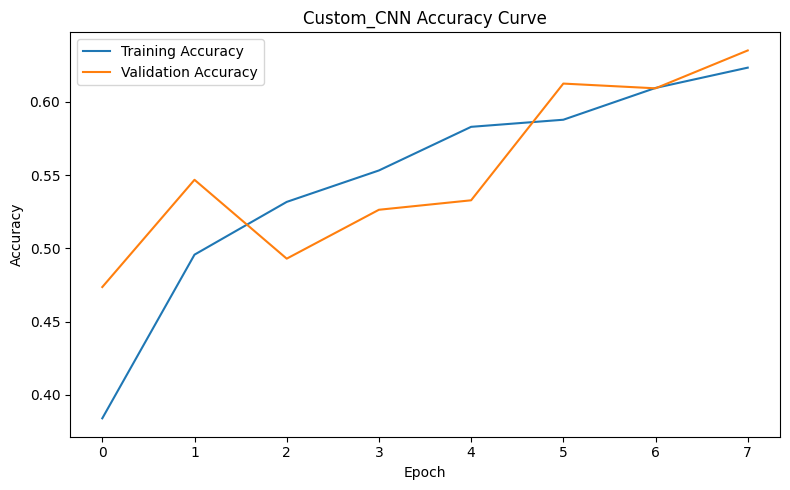

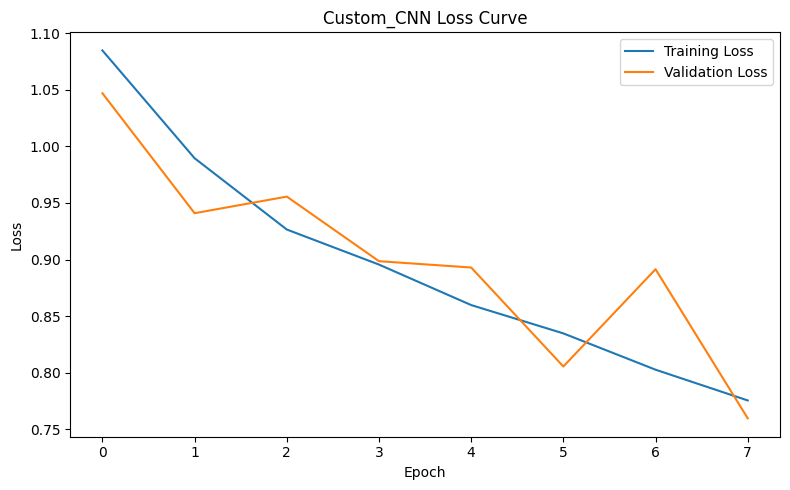

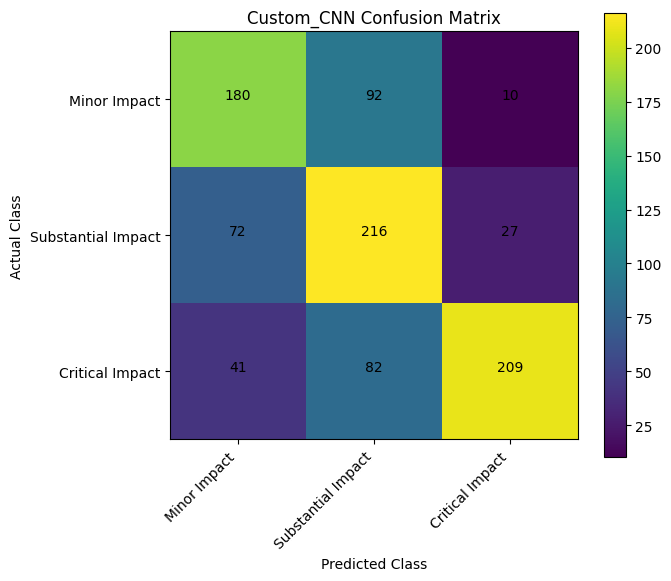

{'Model': 'Custom_CNN',
 'Accuracy': 0.6512,
 'Macro Precision': 0.6726,
 'Macro Recall': 0.6512,
 'Macro F1-Score': 0.654,
 'Weighted F1-Score': 0.6563,
 'Parameters': 421699,
 'Training Time Seconds': 75.76}

In [11]:
# ============================================================
# 10. Model 1: Custom CNN Baseline
# ============================================================
def build_custom_cnn():
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='Custom_CNN')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

custom_cnn = build_custom_cnn()
custom_cnn.summary()

start = time.time()
history_custom = custom_cnn.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=[early_stop, reduce_lr])
custom_time = time.time() - start

plot_training_curves(history_custom, 'Custom_CNN')
custom_results = evaluate_model(custom_cnn, test_ds, 'Custom_CNN')
custom_results['Training Time Seconds'] = round(custom_time, 2)
custom_cnn.save(RESULTS_DIR / 'custom_cnn_model.keras')
custom_results

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Loaded MobileNetV2 ImageNet weights.


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 16s 77ms/step - accuracy: 0.5317 - loss: 0.9734 - val_accuracy: 0.8009 - val_loss: 0.6131 - learning_rate: 1.0000e-04
Epoch 2/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7939 - loss: 0.5441 - val_accuracy: 0.9225 - val_loss: 0.3396 - learning_rate: 1.0000e-04
Epoch 3/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8925 - loss: 0.3449 - val_accuracy: 0.9602 - val_loss: 0.2194 - learning_rate: 1.0000e-04
Epoch 4/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9183 - loss: 0.2575 - val_accuracy: 0.9785 - val_loss: 0.1551 - learning_rate: 1.0000e-04
Epoch 5/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9499 - loss: 0.1871 - val_accuracy: 0.9774 - val_loss: 0.1260 - learning_rate: 1.0000e-04
Epoch 6/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9543 - loss: 0.1588 - val_accuracy: 0.9828 - val_loss: 0.0868 - learning_rate: 1.0000e-04
Epoch 7/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy:

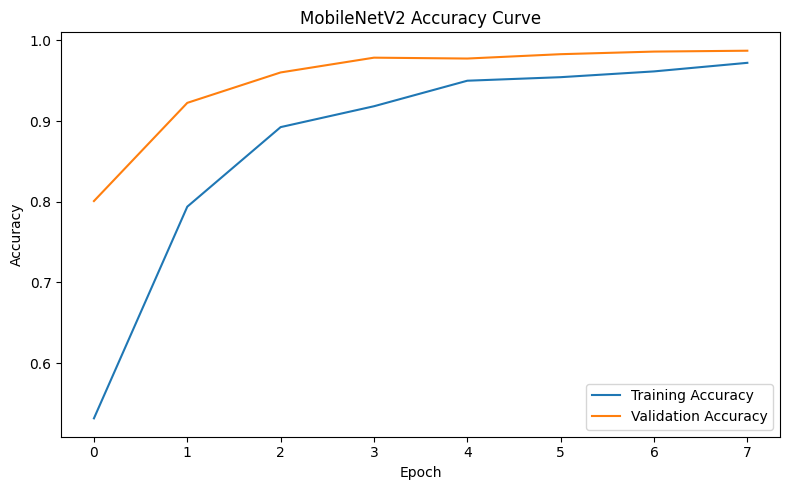

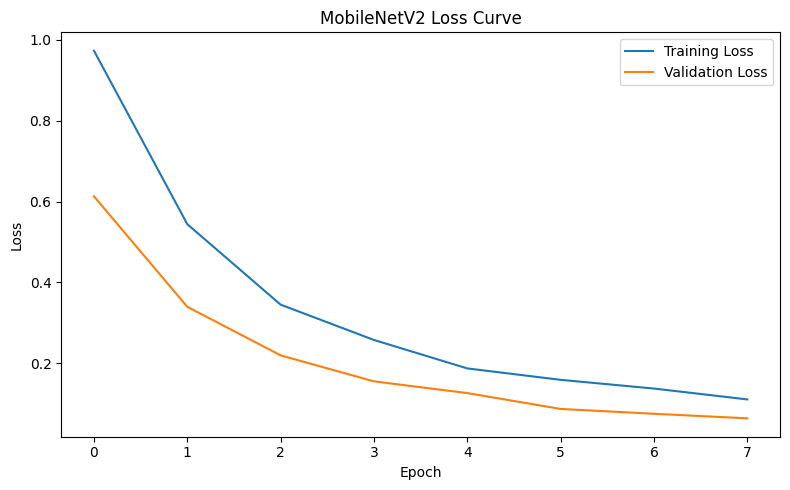

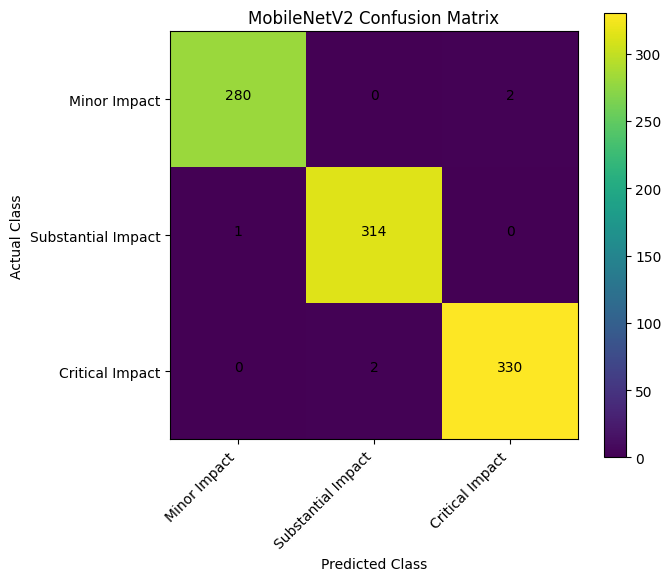

{'Model': 'MobileNetV2',
 'Accuracy': 0.9946,
 'Macro Precision': 0.9947,
 'Macro Recall': 0.9946,
 'Macro F1-Score': 0.9946,
 'Weighted F1-Score': 0.9946,
 'Parameters': 2422339,
 'Training Time Seconds': 77.15}

In [12]:
# ============================================================
# 11. Model 2: MobileNetV2 Transfer Learning
# ============================================================
def build_mobilenetv2():
    try:
        base_model = keras.applications.MobileNetV2(
            input_shape=(224, 224, 3), include_top=False, weights='imagenet'
        )
        print('Loaded MobileNetV2 ImageNet weights.')
    except Exception as e:
        print('Could not load ImageNet weights. Using random initialization instead.')
        print(e)
        base_model = keras.applications.MobileNetV2(
            input_shape=(224, 224, 3), include_top=False, weights=None
        )

    base_model.trainable = False
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='MobileNetV2')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

mobilenet_model = build_mobilenetv2()
mobilenet_model.summary()

start = time.time()
history_mobilenet = mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=[early_stop, reduce_lr])
mobilenet_time = time.time() - start

plot_training_curves(history_mobilenet, 'MobileNetV2')
mobilenet_results = evaluate_model(mobilenet_model, test_ds, 'MobileNetV2')
mobilenet_results['Training Time Seconds'] = round(mobilenet_time, 2)
mobilenet_model.save(RESULTS_DIR / 'mobilenetv2_model.keras')
mobilenet_results

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Loaded EfficientNetB0 ImageNet weights.


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/8


E0000 00:00:1782586013.848702      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


136/136 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - accuracy: 0.3453 - loss: 1.1108 - val_accuracy: 0.3584 - val_loss: 1.1116 - learning_rate: 1.0000e-04
Epoch 2/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.3427 - loss: 1.1074 - val_accuracy: 0.3584 - val_loss: 1.1012 - learning_rate: 1.0000e-04
Epoch 3/8
136/136 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.3404 - loss: 1.1031 - val_accuracy: 0.3584 - val_loss: 1.0973 - learning_rate: 3.0000e-05


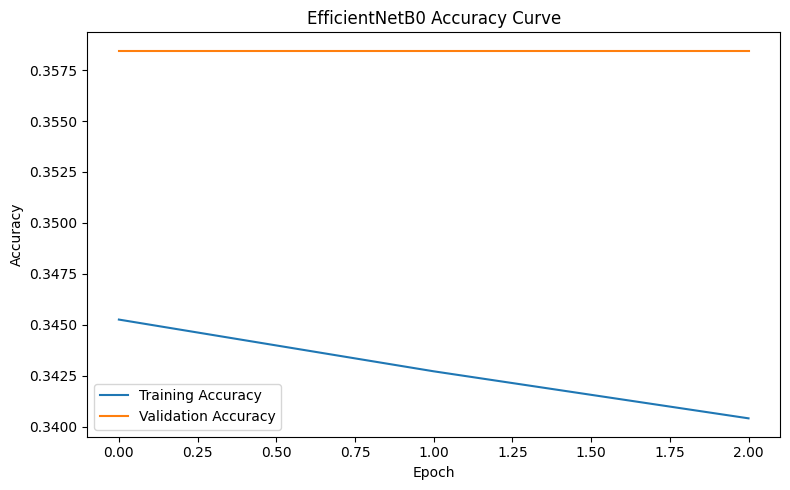

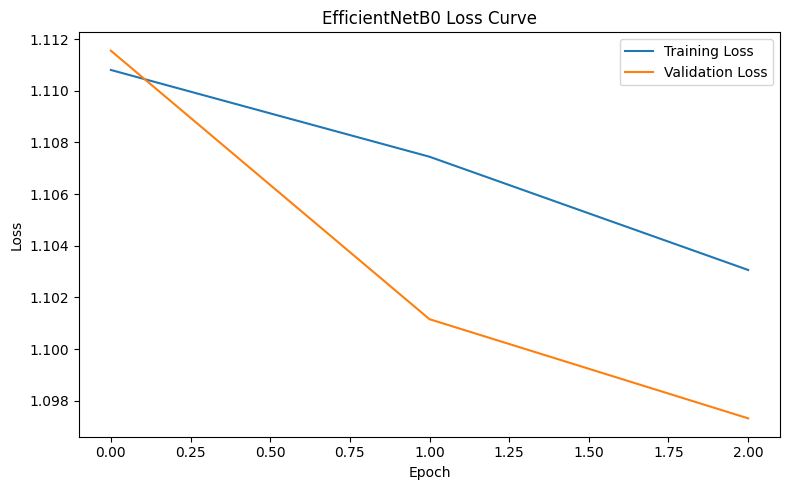

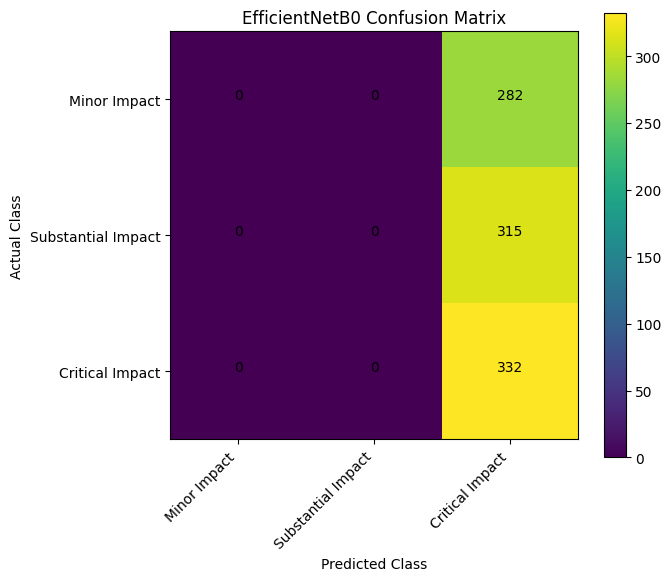

{'Model': 'EfficientNetB0',
 'Accuracy': 0.3574,
 'Macro Precision': 0.1191,
 'Macro Recall': 0.3333,
 'Macro F1-Score': 0.1755,
 'Weighted F1-Score': 0.1882,
 'Parameters': 4213926,
 'Training Time Seconds': 48.04}

In [13]:
# ============================================================
# 12. Model 3: EfficientNetB0 Transfer Learning
# ============================================================
def build_efficientnetb0():
    try:
        base_model = keras.applications.EfficientNetB0(
            input_shape=(224, 224, 3), include_top=False, weights='imagenet'
        )
        print('Loaded EfficientNetB0 ImageNet weights.')
    except Exception as e:
        print('Could not load ImageNet weights. Using random initialization instead.')
        print(e)
        base_model = keras.applications.EfficientNetB0(
            input_shape=(224, 224, 3), include_top=False, weights=None
        )

    base_model.trainable = False
    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name='EfficientNetB0')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

efficientnet_model = build_efficientnetb0()
efficientnet_model.summary()

start = time.time()
history_efficientnet = efficientnet_model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=[early_stop, reduce_lr])
efficientnet_time = time.time() - start

plot_training_curves(history_efficientnet, 'EfficientNetB0')
efficientnet_results = evaluate_model(efficientnet_model, test_ds, 'EfficientNetB0')
efficientnet_results['Training Time Seconds'] = round(efficientnet_time, 2)
efficientnet_model.save(RESULTS_DIR / 'efficientnetb0_model.keras')
efficientnet_results

In [14]:
# ============================================================
# 13. Model Comparison Table
# ============================================================
results = [custom_results, mobilenet_results, efficientnet_results]
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by='Macro F1-Score', ascending=False).reset_index(drop=True)
comparison_df.to_csv(RESULTS_DIR / 'model_comparison_table.csv', index=False)
comparison_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted F1-Score,Parameters,Training Time Seconds
0,MobileNetV2,0.9946,0.9947,0.9946,0.9946,0.9946,2422339,77.15
1,Custom_CNN,0.6512,0.6726,0.6512,0.6540,0.6563,421699,75.76
2,EfficientNetB0,0.3574,0.1191,0.3333,0.1755,0.1882,4213926,48.04


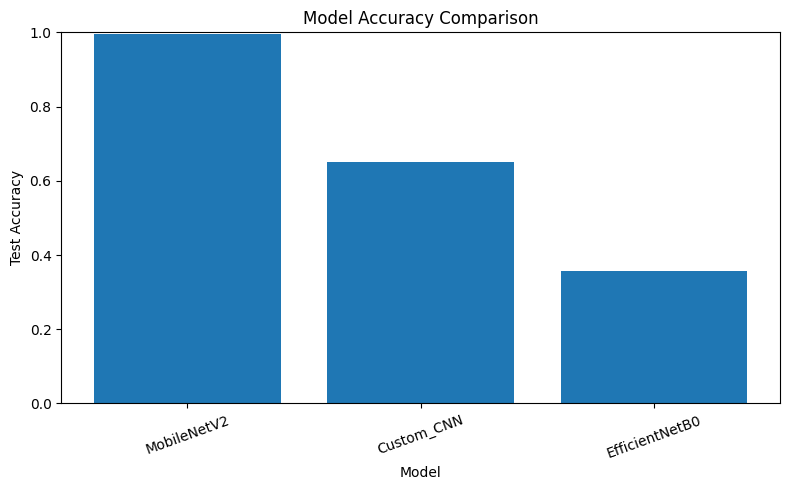

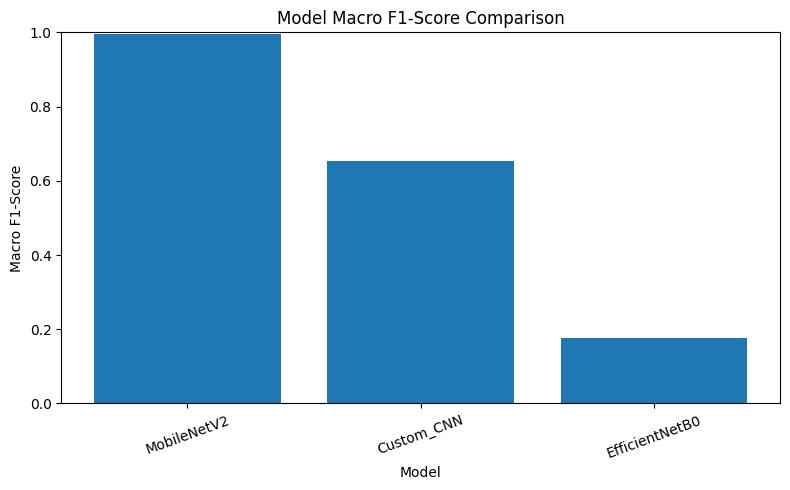

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Accuracy'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_accuracy_comparison.png', dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['Model'], comparison_df['Macro F1-Score'])
plt.title('Model Macro F1-Score Comparison')
plt.xlabel('Model')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model_f1_comparison.png', dpi=300)
plt.show()

In [16]:
# ============================================================
# 14. Save Best Model and Class Names
# ============================================================
best_model_name = comparison_df.iloc[0]['Model']
print('Best model:', best_model_name)

if best_model_name == 'Custom_CNN':
    best_model = custom_cnn
elif best_model_name == 'MobileNetV2':
    best_model = mobilenet_model
else:
    best_model = efficientnet_model

best_model.save('/kaggle/working/best_accident_severity_model.keras')
best_model.save(RESULTS_DIR / 'best_accident_severity_model.keras')

with open(RESULTS_DIR / 'class_names.json', 'w') as f:
    json.dump(class_names, f)

summary = {
    'project_title': 'CNN-Based Road Accident Severity Classification Using Transfer Learning',
    'dataset': 'Road Accidents from CCTV Footages Dataset',
    'classes': class_names,
    'best_model': best_model_name,
    'best_model_accuracy': float(comparison_df.iloc[0]['Accuracy']),
    'best_model_macro_f1': float(comparison_df.iloc[0]['Macro F1-Score'])
}
with open(RESULTS_DIR / 'project_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

summary

Best model: MobileNetV2


{'project_title': 'CNN-Based Road Accident Severity Classification Using Transfer Learning',
 'dataset': 'Road Accidents from CCTV Footages Dataset',
 'classes': ['Minor Impact', 'Substantial Impact', 'Critical Impact'],
 'best_model': 'MobileNetV2',
 'best_model_accuracy': 0.9946,
 'best_model_macro_f1': 0.9946}

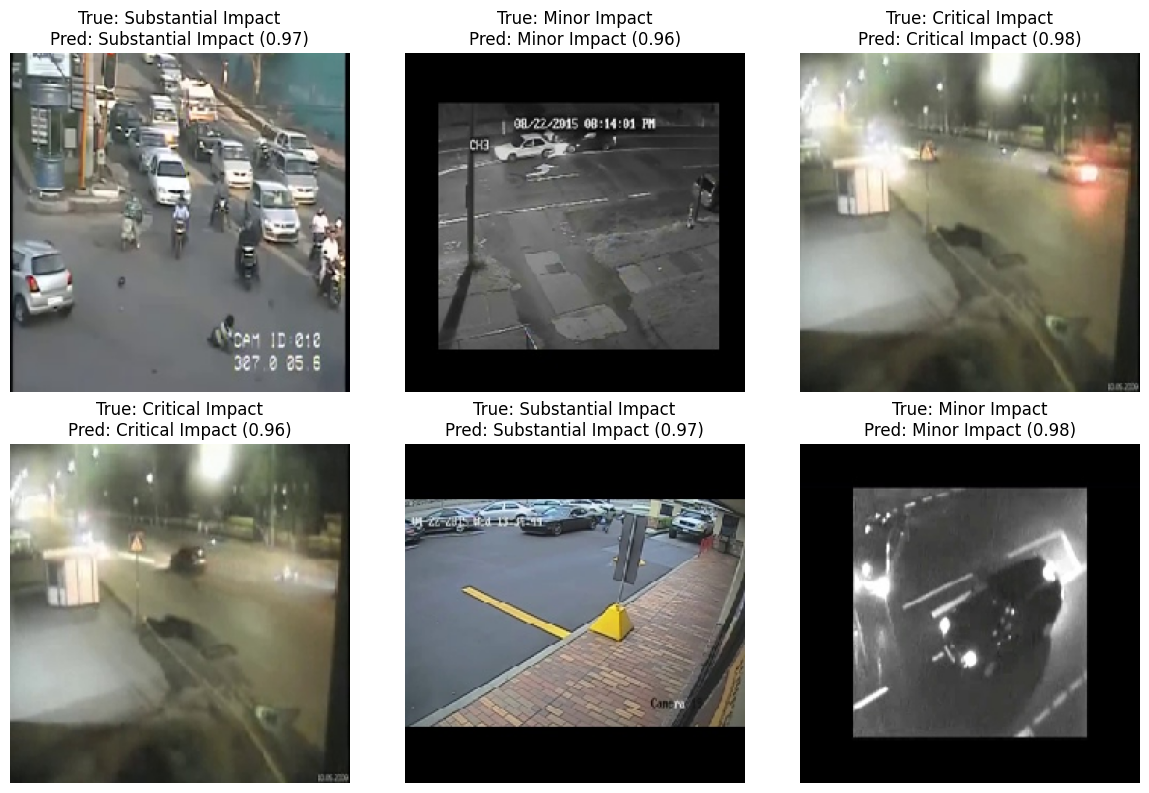

In [17]:
# ============================================================
# 15. Test Prediction on Random Images
# ============================================================
def predict_single_image(model, image_path):
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return class_names[pred_idx], float(np.max(probs)), probs

sample_test = test_df.sample(6, random_state=SEED)
plt.figure(figsize=(12, 8))
for i, row in enumerate(sample_test.itertuples(), start=1):
    pred_class, confidence, probs = predict_single_image(best_model, row.filepath)
    img = keras.utils.load_img(row.filepath, target_size=IMG_SIZE)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(f'True: {row.label_name}\nPred: {pred_class} ({confidence:.2f})')
    plt.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_predictions.png', dpi=300)
plt.show()


In [18]:
# ============================================================
# 16. Generate Streamlit Frontend Files
# ============================================================
frontend_dir = Path('/kaggle/working/frontend')
frontend_dir.mkdir(parents=True, exist_ok=True)

app_code = r"""
import json
import numpy as np
import streamlit as st
import tensorflow as tf
from tensorflow import keras
from PIL import Image

st.set_page_config(page_title='Road Accident Severity Classifier', layout='centered')

st.title('Road Accident Severity Classification')
st.write('Upload a road accident image. The model predicts whether the severity is Minor Impact, Substantial Impact, or Critical Impact.')

MODEL_PATH = 'best_accident_severity_model.keras'
CLASS_NAMES = ['Minor Impact', 'Substantial Impact', 'Critical Impact']
IMG_SIZE = (224, 224)

@st.cache_resource
def load_model():
    return keras.models.load_model(MODEL_PATH)

model = load_model()

uploaded_file = st.file_uploader('Upload accident image', type=['jpg', 'jpeg', 'png', 'webp'])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', use_container_width=True)

    resized = image.resize(IMG_SIZE)
    arr = np.array(resized).astype('float32') / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr)[0]
    pred_idx = int(np.argmax(probs))
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(np.max(probs))

    st.subheader('Prediction Result')
    st.success(f'Predicted Severity: {pred_class}')
    st.write(f'Confidence: {confidence:.2%}')

    st.subheader('Class Probabilities')
    for cls, prob in zip(CLASS_NAMES, probs):
        st.write(f'{cls}: {prob:.2%}')
"""

requirements = """
streamlit
tensorflow
numpy
pillow
"""

readme = """
# Road Accident Severity Classification Frontend

This Streamlit app loads the trained CNN model and predicts accident severity from an uploaded image.

## Classes
- Minor Impact
- Substantial Impact
- Critical Impact

## Run locally
```bash
pip install -r requirements.txt
streamlit run app.py
```

Make sure `best_accident_severity_model.keras` is in the same folder as `app.py`.
"""

(frontend_dir / 'app.py').write_text(app_code)
(frontend_dir / 'requirements.txt').write_text(requirements)
(frontend_dir / 'README.md').write_text(readme)

# Copy best model to frontend folder
shutil.copy('/kaggle/working/best_accident_severity_model.keras', frontend_dir / 'best_accident_severity_model.keras')

print('Frontend files created in:', frontend_dir)

Frontend files created in: /kaggle/working/frontend


In [19]:
# ============================================================
# 17. Create ZIP Files for Submission
# ============================================================
shutil.make_archive('/kaggle/working/results', 'zip', RESULTS_DIR)
shutil.make_archive('/kaggle/working/frontend', 'zip', '/kaggle/working/frontend')

print('Created files:')
print('/kaggle/working/results.zip')
print('/kaggle/working/frontend.zip')
print('/kaggle/working/best_accident_severity_model.keras')

print('Files in /kaggle/working:')
for p in Path('/kaggle/working').iterdir():
    print(p)

Created files:
/kaggle/working/results.zip
/kaggle/working/frontend.zip
/kaggle/working/best_accident_severity_model.keras
Files in /kaggle/working:
/kaggle/working/best_accident_severity_model.keras
/kaggle/working/frontend
/kaggle/working/frontend.zip
/kaggle/working/.virtual_documents
/kaggle/working/results
/kaggle/working/results.zip


## Final Phase 2 Checklist

After running all cells successfully, download from Kaggle output:

1. `results.zip`
2. `frontend.zip`
3. `best_accident_severity_model.keras`
4. The executed Kaggle notebook `.ipynb`

Then upload them to GitHub and make the repository public.

Recommended repository structure:

```text
road-accident-severity-classification/
├── notebook.ipynb
├── results.zip
├── best_accident_severity_model.keras
├── frontend/
│   ├── app.py
│   ├── requirements.txt
│   └── README.md
└── README.md
```